In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('/Users/kolim/Projects/localexpert/data/sample_biobehavioral.csv')
print("Shape:", df.shape)
print("\nDtypes:")
print(df.dtypes)
print("\nHead:")
print(df.head())

Shape: (300, 6)

Dtypes:
participant_id      int64
age                 int64
sex                   str
caffeine_mg       float64
stress_score      float64
rmssd             float64
dtype: object

Head:
   participant_id  age sex  caffeine_mg  stress_score  rmssd
0               1   42   M        220.5           1.1  59.93
1               2   25   M          9.8           1.8  65.62
2               3   33   M        515.8           5.4  47.91
3               4   44   M        244.8           4.8  40.25
4               5   53   F         53.4           1.7    NaN


In [ ]:
# Missingness per variable (as percent)
missing_per_var = df.isna().mean() * 100
print("=== Missingness per variable (%) ===")
print(missing_per_var.sort_values(ascending=False))

print("\n=== Total missing cells ===")
print(f"{df.isna().sum().sum()} out of {df.size} cells ({df.isna().sum().sum()/df.size*100:.2f}%)")

# Missingness per row (as percent)
missing_per_row = df.isna().mean(axis=1) * 100
print("\n=== Missingness per row (%) — summary statistics ===")
print(missing_per_row.describe())

print("\n=== Distribution of missingness per row ===")
print(missing_per_row.value_counts().sort_index())

=== Missingness per variable (%) ===
caffeine_mg       7.000000
rmssd             3.333333
participant_id    0.000000
age               0.000000
sex               0.000000
stress_score      0.000000
dtype: float64

=== Total missing cells ===
31 out of 1800 cells (1.72%)

=== Missingness per row (%) — summary statistics ===
count    300.000000
mean       1.722222
std        5.261348
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max       33.333333
dtype: float64

=== Distribution of missingness per row ===
0.000000     270
16.666667     29
33.333333      1
Name: count, dtype: int64


In [ ]:
from scipy import stats

continuous_vars = ['age', 'caffeine_mg', 'stress_score', 'rmssd']

# Compute descriptive metrics
desc_df = pd.DataFrame()
for var in continuous_vars:
    series = df[var].dropna()
    desc_df.loc['mean', var] = series.mean()
    desc_df.loc['median', var] = series.median()
    desc_df.loc['std', var] = series.std()
    desc_df.loc['skewness', var] = stats.skew(series)
    desc_df.loc['kurtosis', var] = stats.kurtosis(series)  # excess kurtosis
    desc_df.loc['n_valid', var] = len(series)

desc_df.index.name = 'metric'
print("=== Descriptive Statistics for Continuous Variables ===")
print(desc_df.round(4))

=== Descriptive Statistics for Continuous Variables ===
               age  caffeine_mg  stress_score     rmssd
metric                                                 
mean       37.3467     187.4785        3.3747   61.0733
median     37.0000     155.0000        3.2000   57.4550
std        12.1030     122.0244        1.8274   25.9316
skewness    0.1449       1.0249        0.4347    5.2902
kurtosis   -0.6377       0.5232       -0.4242   32.2846
n_valid   300.0000     279.0000      300.0000  290.0000


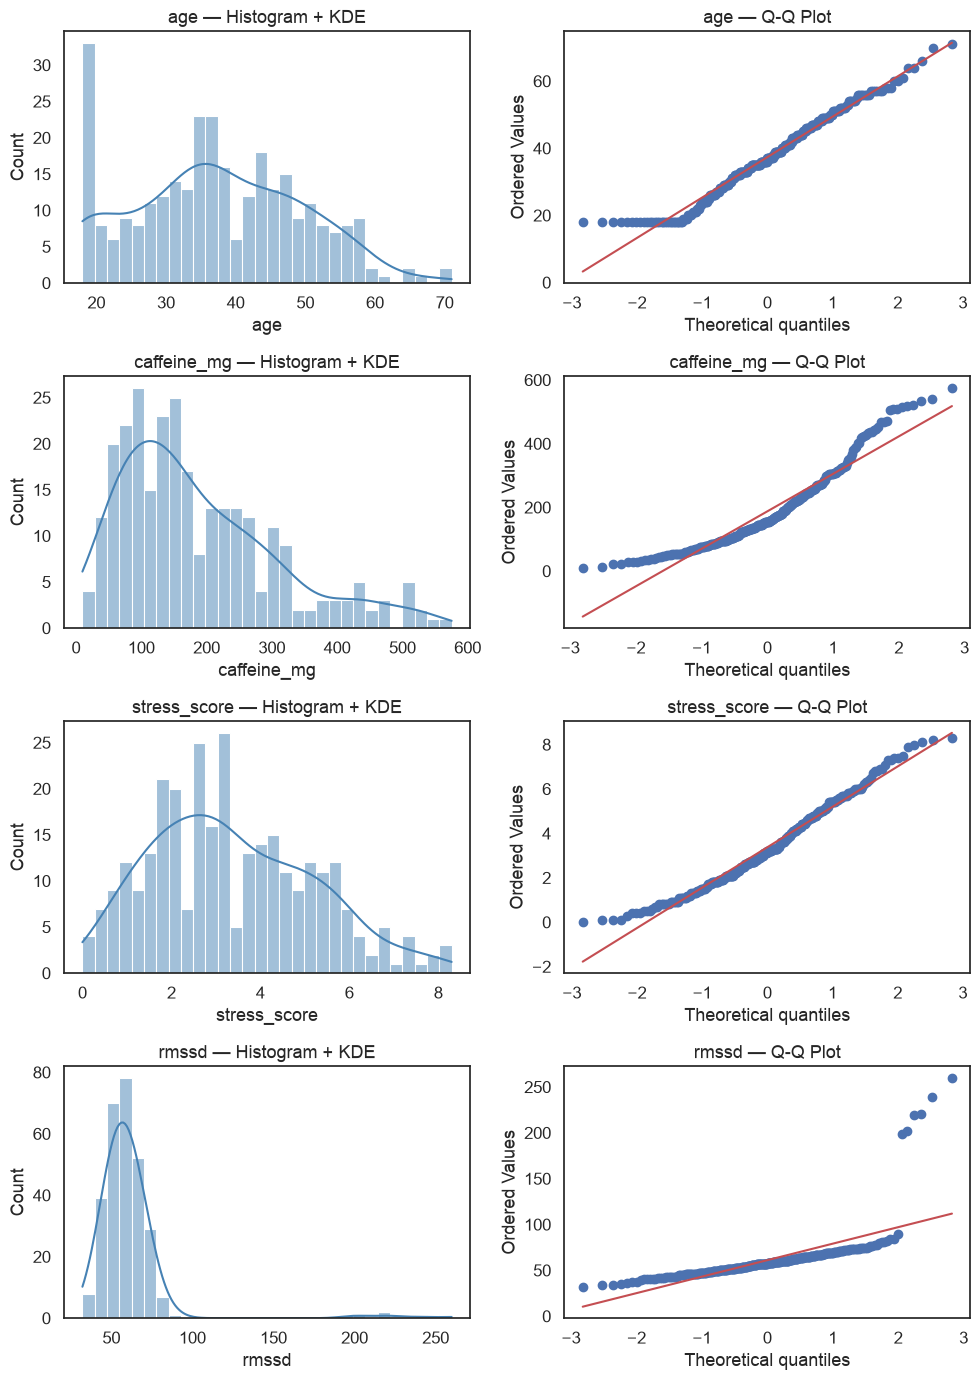

Plot saved to /tmp/eda_distributions.png


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set style
sns.set_theme(style="white", font_scale=1.1)

fig, axes = plt.subplots(4, 2, figsize=(10, 14))
continuous_vars = ['age', 'caffeine_mg', 'stress_score', 'rmssd']

for i, var in enumerate(continuous_vars):
    series = df[var].dropna()
    
    # Histogram + KDE
    ax_hist = axes[i, 0]
    sns.histplot(series, kde=True, bins=30, color='steelblue', ax=ax_hist)
    ax_hist.set_title(f'{var} — Histogram + KDE')
    ax_hist.set_xlabel(var)
    
    # Q-Q plot
    ax_qq = axes[i, 1]
    stats.probplot(series, dist="norm", plot=ax_qq)
    ax_qq.set_title(f'{var} — Q-Q Plot')

plt.tight_layout()
plt.savefig('/tmp/eda_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to /tmp/eda_distributions.png")

In [ ]:
# --- Probe for caffeine_mg missingness ---
has_caffeine = df[df['caffeine_mg'].notna()]
missing_caffeine = df[df['caffeine_mg'].isna()]

print("=== Caffeine_mg: Observed vs. Missing — covariate comparison ===")
compare_df = pd.DataFrame({
    'age_mean': [has_caffeine['age'].mean(), missing_caffeine['age'].mean()],
    'stress_score_mean': [has_caffeine['stress_score'].mean(), missing_caffeine['stress_score'].mean()],
    'rmssd_mean': [has_caffeine['rmssd'].mean(), missing_caffeine['rmssd'].dropna().mean()],
})
compare_df.index = ['caffeine_present', 'caffeine_missing']
print(compare_df.round(4))

# T-tests to see if differences are significant
for col in ['age', 'stress_score']:
    present_vals = has_caffeine[col]
    missing_vals = missing_caffeine[col]
    t_stat, p_val = stats.ttest_ind(present_vals, missing_vals, equal_var=False)
    print(f"\n  {col}: t={t_stat:.3f}, p={p_val:.4f}")

# Sex distribution comparison
print("\n=== Caffeine: sex distribution ===")
print("Present:")
print(has_caffeine['sex'].value_counts(normalize=True))
print("\nMissing:")
print(missing_caffeine['sex'].value_counts(normalize=True))

=== Caffeine_mg: Observed vs. Missing — covariate comparison ===
                  age_mean  stress_score_mean  rmssd_mean
caffeine_present   37.3548             3.3566     61.4849
caffeine_missing   37.2381             3.6143     55.5165

  age: t=0.047, p=0.9628

  stress_score: t=-0.534, p=0.5987

=== Caffeine: sex distribution ===
Present:
sex
F    0.616487
M    0.383513
Name: proportion, dtype: float64

Missing:
sex
F    0.52381
M    0.47619
Name: proportion, dtype: float64


In [ ]:
# --- Probe for rmssd missingness ---
has_rmssd = df[df['rmssd'].notna()]
missing_rmssd = df[df['rmssd'].isna()]

print("=== RMSSD: Observed vs. Missing — covariate comparison ===")
compare_df2 = pd.DataFrame({
    'age_mean': [has_rmssd['age'].mean(), missing_rmssd['age'].mean()],
    'stress_score_mean': [has_rmssd['stress_score'].mean(), missing_rmssd['stress_score'].mean()],
})
# For caffeine, handle the fact that some rmssd-missing rows also have caffeine missing
compare_df2.loc['rmssd_present', 'caffeine_mean'] = has_rmssd['caffeine_mg'].mean()
# Only compare among those with both available or separately
caffeine_both = df[df['rmssd'].notna() & df['caffeine_mg'].notna()]
missing_rmssd_with_caff = missing_rmssd[missing_rmssd['caffeine_mg'].notna()]

print(compare_df2.round(4))

# T-tests
for col in ['age', 'stress_score']:
    present_vals = has_rmssd[col]
    missing_vals = missing_rmssd[col]
    t_stat, p_val = stats.ttest_ind(present_vals, missing_vals, equal_var=False)
    print(f"\n  {col}: t={t_stat:.3f}, p={p_val:.4f}")

# Sex distribution comparison
print("\n=== RMSSD: sex distribution ===")
print("Present:")
print(has_rmssd['sex'].value_counts(normalize=True))
print("\nMissing:")
print(missing_rmssd['sex'].value_counts(normalize=True))

# Caffeine comparison (only among those with caffeine data in both groups)
if len(caffeine_both) > 1 and len(missing_rmssd_with_caff) > 1:
    t_stat, p_val = stats.ttest_ind(
        caffeine_both['caffeine_mg'], 
        missing_rmssd_with_caff['caffeine_mg'], 
        equal_var=False
    )
    print(f"\n  caffeine_mg (both valid): present_mean={caffeine_both['caffeine_mg'].mean():.2f}, "
          f"missing_mean={missing_rmssd_with_caff['caffeine_mg'].mean():.2f}, "
          f"t={t_stat:.3f}, p={p_val:.4f}")

# Also check the row with both missing (33.33% missing)
print("\n=== Row(s) with BOTH caffeine_mg and rmssd missing ===")
both_missing = df[df['caffeine_mg'].isna() & df['rmssd'].isna()]
print(both_missing.to_string())

=== RMSSD: Observed vs. Missing — covariate comparison ===
               age_mean  stress_score_mean  caffeine_mean
0                36.731             3.3928            NaN
1                55.200             2.8500            NaN
rmssd_present       NaN                NaN       187.0248

  age: t=-8.604, p=0.0000

  stress_score: t=0.786, p=0.4510

=== RMSSD: sex distribution ===
Present:
sex
F    0.610345
M    0.389655
Name: proportion, dtype: float64

Missing:
sex
F    0.6
M    0.4
Name: proportion, dtype: float64

  caffeine_mg (both valid): present_mean=187.02, missing_mean=201.09, t=-0.351, p=0.7337

=== Row(s) with BOTH caffeine_mg and rmssd missing ===
     participant_id  age sex  caffeine_mg  stress_score  rmssd
110             111   56   F          NaN           0.8    NaN


=== Participants missing RMSSD ===
     participant_id  age sex  caffeine_mg
4                 5   53   F         53.4
7                 8   52   F        246.8
107             108   44   F         90.4
110             111   56   F          NaN
118             119   56   M        322.1
182             183   58   F        175.8
188             189   70   M        144.9
204             205   55   M        166.8
208             209   54   F        174.4
257             258   54   M        435.2

=== Age distribution: rmssd present vs. missing ===


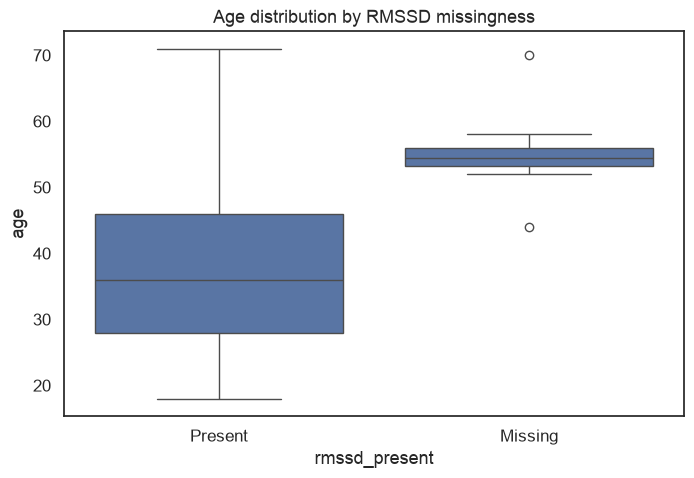

In [ ]:
# Which participants are missing rmssd? Check their ages
missing_rmssd_participants = df[df['rmssd'].isna()][['participant_id', 'age', 'sex', 'caffeine_mg']].copy()
print("=== Participants missing RMSSD ===")
print(missing_rmssd_participants.to_string())

print("\n=== Age distribution: rmssd present vs. missing ===")
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(x='rmssd_present', y='age', 
            data=df.assign(rmssd_present=df['rmssd'].notna().map({True: 'Present', False: 'Missing'})),
            ax=ax)
ax.set_title('Age distribution by RMSSD missingness')
plt.savefig('/tmp/age_missingness.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Check caffeine missingness spread across participants
missing_caff_participants = df[df['caffeine_mg'].isna()][['participant_id', 'age', 'sex', 'stress_score']].copy()
print("=== Participants missing Caffeine_mg ===")
print(missing_caff_participants.to_string())

# Check if the 1 row with both missing is among them
both_missing = df[df['caffeine_mg'].isna() & df['rmssd'].isna()]
print(f"\nRows with BOTH caffeine and rmssd missing: {len(both_missing)}")

# Caffeine-missing age stats
print(f"\nCaffeine-missing mean age: {missing_caff_participants['age'].mean():.2f}")
print(f"Caffeine-present mean age: {df[df['caffeine_mg'].notna()]['age'].mean():.2f}")

# Distribution of missing rows by sex for caffeine
print("\nCaffeine-missing sex distribution:")
print(missing_caff_participants['sex'].value_counts(normalize=True))

=== Participants missing Caffeine_mg ===
     participant_id  age sex  stress_score
22               23   41   F           2.9
29               30   27   F           2.8
33               34   41   M           6.5
55               56   46   F           2.7
58               59   41   M           1.8
67               68   34   F           5.2
110             111   56   F           0.8
116             117   28   M           5.7
120             121   18   F           4.3
129             130   18   F           1.1
156             157   47   M           3.6
168             169   48   F           1.2
172             173   43   M           4.7
178             179   32   M           2.5
207             208   33   F           8.2
219             220   37   M           2.3
223             224   49   F           7.9
235             236   37   M           1.3
236             237   49   F           3.4
248             249   18   M           4.7
256             257   39   M           2.3

Rows with BO